# Import library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data files load

In [3]:
df = pd.read_csv("Automobile_data.csv")
df.head(2)

,index,company,body_style,wheel_base,length,engine_type,num_of_cylinders,horsepower,mileage,price
0,0,alfa-romero,convertible,88.6,168.8,dohc,four,111,21,13495.0
1,1,alfa-romero,convertible,88.6,168.8,dohc,four,111,21,16500.0


In [4]:
df.shape

(61, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   index             61 non-null     int64  
 1   company           61 non-null     object 
 2   body_style        61 non-null     object 
 3   wheel_base        61 non-null     float64
 4   length            61 non-null     float64
 5   engine_type       61 non-null     object 
 6   num_of_cylinders  61 non-null     object 
 7   horsepower        61 non-null     int64  
 8   mileage           61 non-null     int64  
 9   price             58 non-null     float64
dtypes: float64(3), int64(3), object(4)
memory usage: 4.9+ KB


In [7]:
df[df.price.isna()]

,index,company,body_style,wheel_base,length,engine_type,num_of_cylinders,horsepower,mileage,price
22,31,isuzu,sedan,94.5,155.9,ohc,four,70,38,NaN
23,32,isuzu,sedan,94.5,155.9,ohc,four,70,38,NaN
47,63,porsche,hatchback,98.4,175.7,dohcv,eight,288,17,NaN


# Analysis

In [9]:
# Q1. what is the average price and average mileage for convertible cars
df[df.body_style == "convertible"][['price',"mileage"]].mean()

price      22341.000000
mileage       19.666667
dtype: float64

In [12]:
# Q2. Sort cars by company and then price in descending order
df.sort_values(by=['company','price'],ascending=False)

,index,company,body_style,wheel_base,length,engine_type,num_of_cylinders,horsepower,mileage,price
60,88,volvo,wagon,104.3,188.8,ohc,four,114,23,13415.0
59,87,volvo,sedan,104.3,188.8,ohc,four,114,23,12940.0
58,86,volkswagen,sedan,97.3,171.7,ohc,four,100,26,9995.0
57,82,volkswagen,sedan,97.3,171.7,ohc,four,52,37,7995.0
56,81,volkswagen,sedan,97.3,171.7,ohc,four,85,27,7975.0
...,...,...,...,...,...,...,...,...,...,...
5,5,audi,sedan,99.8,177.3,ohc,five,110,19,15250.0
3,3,audi,sedan,99.8,176.6,ohc,four,102,24,13950.0
1,1,alfa-romero,convertible,88.6,168.8,dohc,four,111,21,16500.0
2,2,alfa-romero,hatchback,94.5,171.2,ohcv,six,154,19,16500.0


In [15]:
# Q3. Save data for 'Toyota' separately

df[df.company == 'toyota'].to_csv("toyota data.csv")

In [18]:
# Q4. which company is producing most expensive car?

df.sort_values(by='price' ,ascending=False).head(1)

,index,company,body_style,wheel_base,length,engine_type,num_of_cylinders,horsepower,mileage,price
35,47,mercedes-benz,hardtop,112.0,199.2,ohcv,eight,184,14,45400.0


In [23]:
# Q4. which company is producing most expensive car?

df[df.price == df.price.max()]

,index,company,body_style,wheel_base,length,engine_type,num_of_cylinders,horsepower,mileage,price
35,47,mercedes-benz,hardtop,112.0,199.2,ohcv,eight,184,14,45400.0


In [24]:
# Q5. Name the cars on basis of maximum horsepower
df.sort_values(by='horsepower',ascending=False).head(1)

,index,company,body_style,wheel_base,length,engine_type,num_of_cylinders,horsepower,mileage,price
47,63,porsche,hatchback,98.4,175.7,dohcv,eight,288,17,NaN


In [27]:
# Q6. company wise average price of cars and order them in descending order
df.groupby("company")['price'].mean().sort_values(ascending=False).round()

company
porsche          35528.0
mercedes-benz    35040.0
jaguar           34600.0
bmw              27213.0
audi             16392.0
alfa-romero      15498.0
volvo            13178.0
honda            10195.0
mazda             9655.0
volkswagen        8435.0
nissan            8289.0
toyota            8217.0
isuzu             6785.0
mitsubishi        6689.0
dodge             6303.0
chevrolet         6007.0
Name: price, dtype: float64

In [30]:
# Q7. create a column named: "decision", If wheel-base is more than 100 and length is more than 175 then "Buy" else "Don't buy"?

df['decision'] =  np.where( (df.wheel_base > 100 ) & (df.length > 175 ), "Buy","Dont buy" )

df.sample(10)

,index,company,body_style,wheel_base,length,engine_type,num_of_cylinders,horsepower,mileage,price,decision
0,0,alfa-romero,convertible,88.6,168.8,dohc,four,111,21,13495.0,Dont buy
47,63,porsche,hatchback,98.4,175.7,dohcv,eight,288,17,NaN,Dont buy
18,27,honda,wagon,96.5,157.1,ohc,four,76,30,7295.0,Dont buy
58,86,volkswagen,sedan,97.3,171.7,ohc,four,100,26,9995.0,Dont buy
14,17,chevrolet,hatchback,94.5,155.9,ohc,four,70,38,6295.0,Dont buy
21,30,isuzu,sedan,94.3,170.7,ohc,four,78,24,6785.0,Dont buy
11,14,bmw,sedan,103.5,193.8,ohc,six,182,16,41315.0,Buy
30,39,mazda,hatchback,95.3,169.0,rotor,two,101,17,11845.0,Dont buy
4,4,audi,sedan,99.4,176.6,ohc,five,115,18,17450.0,Dont buy
48,66,toyota,hatchback,95.7,158.7,ohc,four,62,35,5348.0,Dont buy


In [31]:
# Q8. Select only cars whose decision is "buy"?
df[df.decision == "Buy"]

,index,company,body_style,wheel_base,length,engine_type,num_of_cylinders,horsepower,mileage,price,decision
6,6,audi,wagon,105.8,192.7,ohc,five,110,19,18920.0,Buy
7,9,bmw,sedan,101.2,176.8,ohc,four,101,23,16430.0,Buy
8,10,bmw,sedan,101.2,176.8,ohc,four,101,23,16925.0,Buy
9,11,bmw,sedan,101.2,176.8,ohc,six,121,21,20970.0,Buy
10,13,bmw,sedan,103.5,189.0,ohc,six,182,16,30760.0,Buy
11,14,bmw,sedan,103.5,193.8,ohc,six,182,16,41315.0,Buy
12,15,bmw,sedan,110.0,197.0,ohc,six,182,15,36880.0,Buy
24,33,jaguar,sedan,113.0,199.6,dohc,six,176,15,32250.0,Buy
25,34,jaguar,sedan,113.0,199.6,dohc,six,176,15,35550.0,Buy
26,35,jaguar,sedan,102.0,191.7,ohcv,twelve,262,13,36000.0,Buy


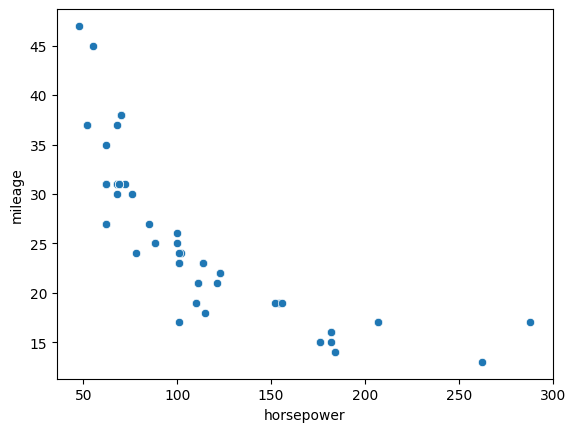

In [37]:
# Q9. Find is there any relation between horse power and mileage? 
sns.scatterplot(data=df,x='horsepower',y='mileage')
plt.show()